<a href="https://colab.research.google.com/github/boskovicgroup/Linegraph_github/blob/main/centrality_analyses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install RDKit in Google Colab environment; bang ! means use shell command for installing
%%capture
!pip install rdkit

In [45]:
from rdkit import Chem
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

In [ ]:
def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)

    G = nx.Graph()

    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(),
                   element=atom.GetSymbol())

    for bond in mol.GetBonds():
        G.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            order=bond.GetBondTypeAsDouble()
        )

    return G

In [ ]:
def prune_to_core(G):
    G = G.copy()

    changed = True

    while changed:
        changed = False
        terminal = [n for n in G.nodes if G.degree[n] == 1]

        if terminal:
            G.remove_nodes_from(terminal)
            changed = True

    return G

In [38]:
# paste your SMILES here
smiles = "O[C@@H](C[C@H]1C([H])([C@H]2OC)[C@H](CC3)[C@]4(C[C@]5(O)C)C[C@@]35O)C(C)(C)[C@@]1(O2)[C@H](O)C4";

In [59]:
# get graph from smiles, get line graph from graph, compute betweennees
# centrality for nodes in line graph, z-scale them
G = smiles_to_graph(smiles)
Gp = prune_to_core(G)
LG = nx.line_graph(Gp)
centrality = nx.betweenness_centrality(LG, normalized=False)
cent_values = np.array(list(centrality.values()))

cent_values = np.array(list(centrality.values()))
z = (cent_values - cent_values.mean()) / cent_values.std(ddof=1)

max_node = max(centrality, key=centrality.get)
max_value = centrality[max_node]

print("Most central line graph node:", max_node)
print("Centrality:", max_value)
print("Z-scaled centrality of the most central line graph node is:", max(z))


Most central line graph node: (4, 8)
Centrality: 65.93333333333334
Z-scaled centrality of the most central line graph node is: 2.63195785995422


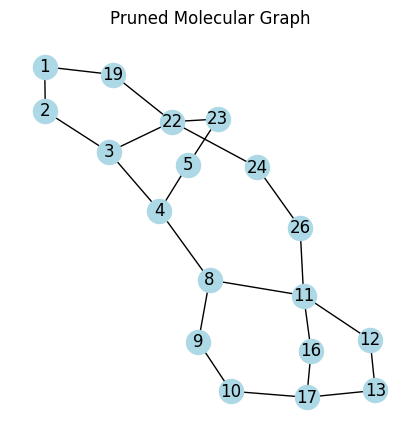

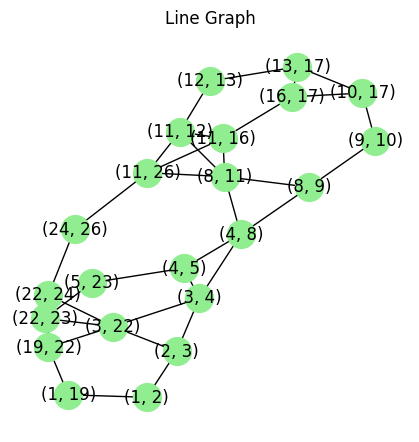

In [61]:
# Plotting
# Original pruned graph G(M)
pos = nx.spring_layout(Gp, seed=42)

plt.figure(figsize=(4,4))
nx.draw(
    Gp,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=300,
)
plt.title("Pruned Molecular Graph")
plt.show()

# Line graph with nodes labeled as pairs of nodes of G(M)
LG = nx.line_graph(Gp)

posLG = nx.spring_layout(LG, seed=42)

plt.figure(figsize=(4,4))
nx.draw(
    LG,
    posLG,
    with_labels=True,
    node_color="lightgreen",
    node_size=400,
)
plt.title("Line Graph")
plt.show()